In [ ]:
import pandas as pd
import openpyxl
from dateutil.relativedelta import relativedelta
from pandas.tseries.offsets import MonthEnd


df = pd.read_excel('Final_Project2_Data.xlsx')
assert df.isnull().sum().sum() == 0, "DataFrame contains missing values"
#print(df.dtypes)
#df.head()
returns = df.copy()

returns = returns.rename(columns = {'Total returns in local currency': 'Date'}).set_index('Date').sort_index()
returns.head()
returns.tail()

In [ ]:
#get most recent 10 years of data for backtesting

backtest_start_date = max(returns.index) - MonthEnd(120) #10 years * 12 months / year = 120 months 
backtest_end_date = max(returns.index)
backtest_data = returns.loc[backtest_start_date:backtest_end_date]
training_data = returns.loc[~returns.index.isin(backtest_data.index)]

print(f"Backtest : {backtest_data.index[0].date()} : {backtest_data.index[-1].date()} | {backtest_data.shape[0]} months")
print(f"Training : {training_data.index[0].date()} : {training_data.index[-1].date()} | {training_data.shape[0]} months")
print(f"Total    : {returns.shape[0]} months | {returns.shape[1]} countries")


Backtest : 2015-12-31 : 2025-12-31 | 121 months
Training : 1970-01-31 : 2015-11-30 | 551 months
Total    : 672 months | 10 countries


In [3]:
train_targets_df = training_data.iloc[36:]
print(f"Training Targets : {train_targets_df.index[0].date()} : {train_targets_df.index[-1].date()} | {train_targets_df.shape[0]} months")
assert relativedelta(min(train_targets_df.index), min(training_data.index)).years == 3, "Check Target Returns Date Range"

Training Targets : 1973-01-31 : 2015-11-30 | 515 months


# Momentum Factors

$$Mom_{i,t} = \prod_{k}^{K}(1+r_{i,t-k}) - 1$$

# Rank Based Approach 

In [7]:

def build_momentum_factor(returns, target_dates, start_lag, end_lag, name='mom'):
    """
    Computes trailing momentum signals for each date in target_dates.

    Parameters
    ----------
    returns      : DataFrame, full return history (used for lookback windows)
    target_dates : DataFrame, dates to compute signals for
    start_lag    : int, months back for start of window (e.g. 12)
    end_lag      : int, months back for end of window (e.g. 2)
    name         : str, column name for output signal

    Returns
    -------
    lagged_cum_returns_df  : (DataFrame, 
                            cumulative country returns over [t-start_lag, t-end_lag] window, 
                            used to construct momentum ranks)
    ranks_df            : DataFrame, cross-sectional rank of each country per date (1=lowest, N=highest)
    unscaled_weights_df : DataFrame, long-short portfolio weights per country per date (sums to 0)

    """

    starts = []
    ends = []
    lagged_cum_returns = []

    for t in target_dates.index:
        start = t - MonthEnd(start_lag)
        end = t - MonthEnd(end_lag)

        assert start in returns.index, f"{start} not found in returns.index"
        assert end in returns.index, f"{end} not found in returns.index"
        
        window = returns.loc[start:end]
        window_returns = (1 + window).prod(axis = 0) - 1
        window_returns.name = t

        starts.append(start)
        ends.append(end)
        lagged_cum_returns.append(window_returns)

    lagged_cum_returns_df = pd.DataFrame(lagged_cum_returns)
    lagged_cum_returns_df.index.name = 'Date'
    lagged_cum_returns_df.insert(0, 'start', starts)
    lagged_cum_returns_df.insert(1, 'end', ends)

    country_cols = lagged_cum_returns_df.columns[2:]
    ranks_df = lagged_cum_returns_df[country_cols].rank(axis = 1, ascending=True, method = 'first') #ascending = True => largest mom. = rank 10 => larger weights 
    unscaled_weights_df = ranks_df.sub(ranks_df.mean(axis = 1), axis = 0)
    #unscaled_weights_df = unscaled_weights_df.div(unscaled_weights_df.abs().sum(axis = 1), axis = 0)

    # raw_returns_df = pd.DataFrame(
    #     (data[country_cols] * weights_df[country_cols]).sum(axis = 1)
    # )
    # raw_returns_df.columns = [f'{name}_return']


    return lagged_cum_returns_df, ranks_df, unscaled_weights_df

# Low Volatility Signal
For each country i and backtest month t, define trailing annualized volatility over window L as:

$$\sigma_{i,t}^{(L)} = \sqrt{(12)}*SD(r_{i,t-L},...,r_{i,t-1})$$


Then define the low-vol signal as:

$$LV_{i,t}^{(L)} = -\sigma_{i,t}^{(L)}$$




In [8]:
def build_lowvol_factor(returns, target_dates, look_back, name = 'low_vol'):

    starts = []
    ends = []
    signals = []

    for t in target_dates.index:
        start = t - MonthEnd(look_back)
        end = t - MonthEnd(1)

        assert start in returns.index, f"{start} not found in returns.index"
        assert end in returns.index, f"{end} not found in returns.index"

        window = returns.loc[start:end]
        
        #lower vol ==> higher signal
        signal = -(window.std(axis = 0) * (12**0.5))
        signal.name = t 

        starts.append(start)
        ends.append(end) 
        signals.append(signal)

    signals_df = pd.DataFrame(signals)
    signals_df.index.name = 'Date'
    signals_df.insert(0, 'start', starts)
    signals_df.insert(1, 'end', ends)

    country_cols = signals_df.columns[2:]
    rank_df = signals_df[country_cols].rank(axis=1, ascending=True, method="first")
    unscaled_weights_df = rank_df.sub(rank_df.mean(axis=1), axis=0)
    unscaled_weights_df = unscaled_weights_df.div(unscaled_weights_df.abs().sum(axis=1), axis=0)

    # raw_returns_df = pd.DataFrame(
    #     (data[country_cols] * weights_df[country_cols]).sum(axis=1)
    # )
    # raw_returns_df.columns = [f"{name}_return"]

    return signals_df, rank_df, unscaled_weights_df


        

# Downside Volatility / Downside Risk 

Rather than total volatility, only penallize bad months. 

For country $i$ at time $t$:

$$DD_{i,t} = \sqrt{12 * \frac{1}{L}\sum_{k=1}^{L}min(r_{i,t-k}, 0)^2}$$

Then define the signal as:

$$signal_{i,t} = -DD_{i,t}$$

- More refined than plain low vol
- Focuses on harmful volatility, not upside variation



In [9]:
def build_downside_vol_factor(returns, target_dates, look_back, name = 'downside_vol'):
    starts = []
    ends = []
    signals = []

    for t in target_dates.index:
        start = t - MonthEnd(look_back)
        end = t - MonthEnd(1)

        assert start in returns.index, f"{start} not found in returns.index"
        assert end in returns.index, f"{end} not found in returns.index"

        window = returns.loc[start:end]
        
        downside = window.clip(upper = 0)
        downside_dev = ((downside**2).mean(axis = 0) * 12) ** 0.5
        signal = -downside_dev
        signal.name = t

        starts.append(start)
        ends.append(end)
        signals.append(signal)

    signals_df = pd.DataFrame(signals)
    signals_df.index.name = 'Date'
    signals_df.insert(0, 'start', starts)
    signals_df.insert(1, 'end', ends)

    country_cols = signals_df.columns[2:]
    rank_df = signals_df[country_cols].rank(axis=1, ascending=True, method="first")
    weights_df = rank_df.sub(rank_df.mean(axis=1), axis=0)
    weights_df = weights_df.div(weights_df.abs().sum(axis=1), axis=0)

    # raw_returns_df = pd.DataFrame(
    #     (target_dates[country_cols] * weights_df[country_cols]).sum(axis=1)
    # )
    # raw_returns_df.columns = [f"{name}_return"]

    return signals_df, rank_df, weights_df


        

# Estimated Covariance Matrices 
Per Assignment Requirements:
- Covariance matrix of assets must be estimated and updated at least every month
- Each estimation must use at least 36 months of prior returns (3 years) 

Let $t$ be the backtest month, then:

$$\Sigma_t = 12 * Cov(r_{t-36}, ..., r_{t-1})$$

In [10]:
import numpy as np 
def build_asset_cov_matrices(returns, target_dates, look_back = 36):
    cov_dict = {}
    vol_dict = {}
    corr_dict = {}
    window_map = []

    for t in target_dates.index:
        start = t - MonthEnd(look_back)
        end = t - MonthEnd(1)

        assert start in returns.index, f"{start} not found in returns.index"
        assert end in returns.index, f"{end} not found in returns.index"

        window = returns.loc[start:end]

        cov_t = window.cov() * 12
        vol_t = pd.Series(np.sqrt(np.diag(cov_t)), index = cov_t.index, name = t)
        corr_t = window.corr()

        cov_dict[t] = cov_t
        vol_dict[t] = vol_t
        corr_dict[t] = corr_t

        window_map.append({
            "Date": t,
            "cov_start": start,
            "cov_end": end
        })

    window_map_df = pd.DataFrame(window_map).set_index("Date")

    return cov_dict, vol_dict, corr_dict, window_map_df

# Scaling Factors to Target Volatility 
Per Assignment Requirement:
- Weights for each factor should be scaled to target 1% annual volatility

If $w_t^{raw}$ is the raw factor weight, and $\Sigma_t$ the annualized asset covariance matrix, then the raw factor volatility is:
$$\sigma_t^{raw} = \sqrt{(w_t^{raw})^T\Sigma_tw_t^{raw}}$$
The scaled weights are then:
$$w_t^{scaled} = w_t^{raw} \times \frac{0.01}{\sigma_t^{raw}}$$
Using the scaled weights enforces the factor to target 1% annual volatility for month $t$.

In [29]:
def scale_factor_to_target_vol(unscaled_weights_df, cov_dict, target_vol=0.01):
    scaled_weights = []
    portfolio_risks = []

    for t in unscaled_weights_df.index:
        w = unscaled_weights_df.loc[t]
        cov_t = cov_dict[t].loc[unscaled_weights_df.columns, unscaled_weights_df.columns].values

        portfolio_risk = np.sqrt(w.values @ cov_t @ w.values)
        portfolio_risks.append(portfolio_risk)

        scaled_w = w * (target_vol / portfolio_risk)
        scaled_weights.append(scaled_w)

    scaled_weights_df = pd.DataFrame(scaled_weights, index=unscaled_weights_df.index)
    scaled_weights_df.columns = unscaled_weights_df.columns

    portfolio_risk_df = pd.Series(
        portfolio_risks,
        index=unscaled_weights_df.index,
        name="portfolio_risk"
    )

    return scaled_weights_df, portfolio_risk_df

# Computing realized returns from any weights dataframe

In [6]:
def compute_factor_returns(scaled_factor_weights, target_dates, name = "factor_return"):
    country_cols = scaled_factor_weights.columns
    factor_returns = (target_dates[country_cols] * scaled_factor_weights[country_cols]).sum(axis = 1)
    factor_returns.name = name
    return factor_returns 

# Example:

In [17]:
# training_data 
# train_targets_df
## Build Momentum Factors 
mom121lagged_cum_returns_df, mom121_ranks_df, mom121_unscaled_weights_df = build_momentum_factor(
    training_data, train_targets_df, 12, 1, name = "mom121"
)
## Build lv12 Factors 
lv12_signals_df, lv12_rank_df, lv12_unscaled_weights_df = build_lowvol_factor(
    training_data, train_targets_df, 12, 1
)


mom121_unscaled_weights_df

,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Date,,,,,,,,,,
1973-01-31,-2.5,2.5,0.5,-1.5,-3.5,4.5,1.5,3.5,-4.5,-0.5
1973-02-28,-0.5,2.5,0.5,-1.5,-3.5,4.5,1.5,3.5,-4.5,-2.5
1973-03-31,-3.5,1.5,0.5,-1.5,2.5,4.5,-0.5,3.5,-4.5,-2.5
1973-04-30,-3.5,0.5,-0.5,-1.5,2.5,4.5,1.5,3.5,-4.5,-2.5
1973-05-31,-3.5,-0.5,0.5,-1.5,2.5,4.5,1.5,3.5,-4.5,-2.5
...,...,...,...,...,...,...,...,...,...,...
2015-07-31,-1.5,-4.5,1.5,2.5,-0.5,4.5,3.5,-2.5,-3.5,0.5
2015-08-31,-2.5,-4.5,2.5,1.5,0.5,3.5,4.5,-1.5,-3.5,-0.5
2015-09-30,-2.5,-4.5,2.5,1.5,0.5,4.5,3.5,-1.5,-3.5,-0.5


# Different Mom. Approach --> Demean 

In [24]:
from pandas.tseries.offsets import MonthEnd
import pandas as pd
import numpy as np

def build_momentum_factor2(returns, target_dates, start_lag, end_lag, name='mom'):
    starts = []
    ends = []
    lagged_cum_returns = []

    for t in target_dates.index:
        start = t - MonthEnd(start_lag)
        end = t - MonthEnd(end_lag)

        assert start in returns.index, f"{start} not found in returns.index"
        assert end in returns.index, f"{end} not found in returns.index"

        window = returns.loc[start:end]
        signal = (1 + window).prod(axis=0) - 1
        signal.name = t

        starts.append(start)
        ends.append(end)
        lagged_cum_returns.append(signal)

    lagged_cum_returns_df = pd.DataFrame(lagged_cum_returns)
    lagged_cum_returns_df.index.name = 'Date'
    lagged_cum_returns_df.insert(0, 'start', starts)
    lagged_cum_returns_df.insert(1, 'end', ends)

    country_cols = lagged_cum_returns_df.columns[2:]
    signal_only = lagged_cum_returns_df[country_cols]

    # Homework-style raw factor weights:
    # demean cumulative momentum signal across countries each month
    demeaned = signal_only.sub(signal_only.mean(axis=1), axis=0)

    # divide by cross-sectional std of that month's signals
    row_std = signal_only.std(axis=1).replace(0, np.nan)

    unscaled_weights_df = demeaned.div(row_std, axis=0).fillna(0.0)

    return lagged_cum_returns_df, unscaled_weights_df

In [45]:
mom121_lagged_cum_returns, mom121_unscaled_weights = build_momentum_factor2(training_data, train_targets_df, 12, 1)
cov_dict, vol_dict, corr_dict, window_map_df = build_asset_cov_matrices(training_data, train_targets_df, look_back=36)

mom121_scaled_weights_df, mom121_portfolio_risk_df = scale_factor_to_target_vol(mom121_unscaled_weights, cov_dict, target_vol=0.01 )
mom121_scaled_weights_df

mom121_factor_returns = compute_factor_returns(mom121_scaled_weights_df, train_targets_df)
mom121_factor_returns

Date
1973-01-31    0.001690
1973-02-28   -0.001685
1973-03-31    0.000414
1973-04-30   -0.002574
1973-05-31   -0.000232
                ...   
2015-07-31    0.000548
2015-08-31   -0.002979
2015-09-30   -0.001969
2015-10-31    0.005896
2015-11-30    0.002800
Name: factor_return, Length: 515, dtype: float64

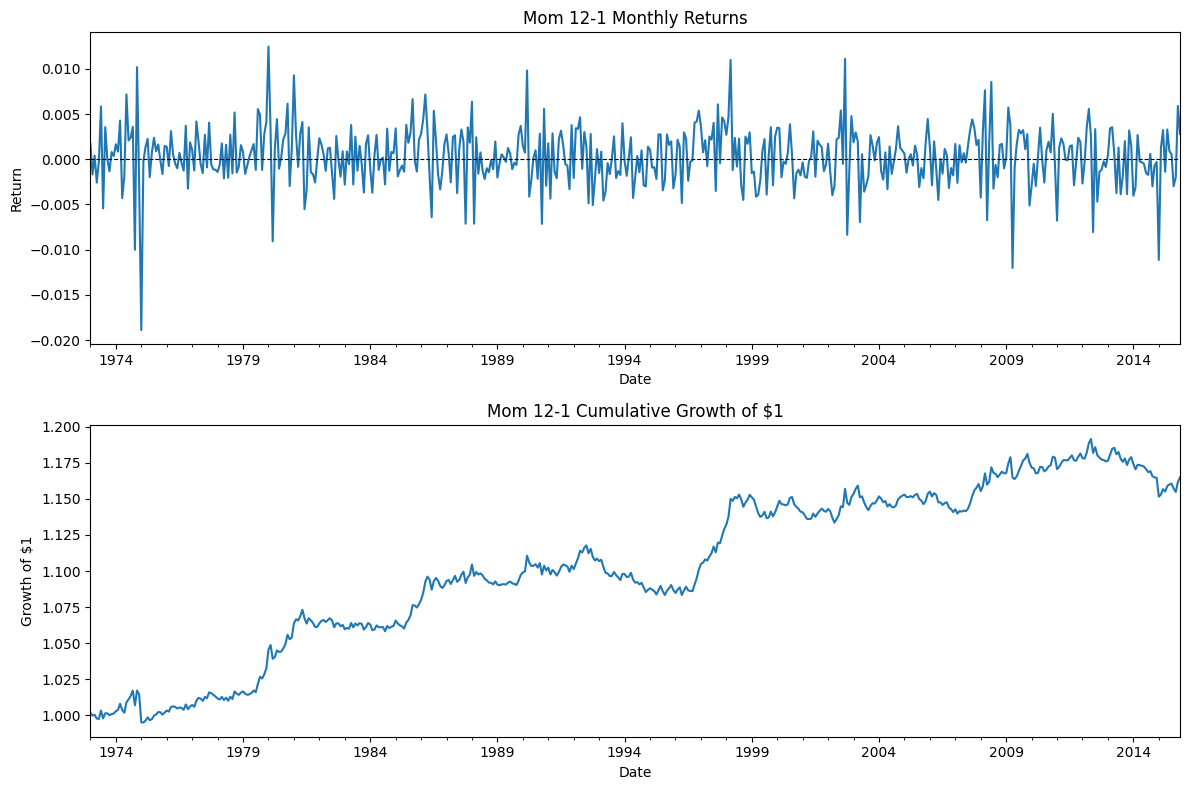

In [46]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Monthly returns
mom121_factor_returns.plot(ax=axes[0], title='Mom 12-1 Monthly Returns')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Return')

# Cumulative growth of $1
(1 + mom121_factor_returns).cumprod().plot(ax=axes[1], title='Mom 12-1 Cumulative Growth of $1')
axes[1].set_ylabel('Growth of $1')

plt.tight_layout()
plt.show()


# Diff LowVol Approach 

In [48]:
from pandas.tseries.offsets import MonthEnd
import pandas as pd
import numpy as np

def build_lowvol_factor(returns, target_dates, look_back, name='low_vol'):
    starts = []
    ends = []
    signals = []

    for t in target_dates.index:
        start = t - MonthEnd(look_back)
        end = t - MonthEnd(1)

        assert start in returns.index, f"{start} not found in returns.index"
        assert end in returns.index, f"{end} not found in returns.index"

        window = returns.loc[start:end]

        # lower vol ==> higher signal
        signal = -(window.std(axis=0) * (12**0.5))
        signal.name = t

        starts.append(start)
        ends.append(end)
        signals.append(signal)

    signals_df = pd.DataFrame(signals)
    signals_df.index.name = 'Date'
    signals_df.insert(0, 'start', starts)
    signals_df.insert(1, 'end', ends)

    country_cols = signals_df.columns[2:]
    signal_only = signals_df[country_cols]

    # signal-based raw weights: demean the signal cross-sectionally
    unscaled_weights_df = signal_only.sub(signal_only.mean(axis=1), axis=0)

    # optional: normalize gross exposure to 1, matching your friend's logic
    abs_sum = unscaled_weights_df.abs().sum(axis=1).replace(0, np.nan)
    unscaled_weights_df = unscaled_weights_df.div(abs_sum, axis=0).fillna(0.0)

    return signals_df, unscaled_weights_df

# Momentum Approach 3 Demeanded / div by abs value

In [57]:
from pandas.tseries.offsets import MonthEnd
import pandas as pd
import numpy as np

def build_momentum_factor2(returns, target_dates, start_lag, end_lag, name='mom'):
    starts = []
    ends = []
    lagged_cum_returns = []

    for t in target_dates.index:
        start = t - MonthEnd(start_lag)
        end = t - MonthEnd(end_lag)

        assert start in returns.index, f"{start} not found in returns.index"
        assert end in returns.index, f"{end} not found in returns.index"

        window = returns.loc[start:end]
        signal = (1 + window).prod(axis=0) - 1
        signal.name = t

        starts.append(start)
        ends.append(end)
        lagged_cum_returns.append(signal)

    lagged_cum_returns_df = pd.DataFrame(lagged_cum_returns)
    lagged_cum_returns_df.index.name = 'Date'
    lagged_cum_returns_df.insert(0, 'start', starts)
    lagged_cum_returns_df.insert(1, 'end', ends)

    country_cols = lagged_cum_returns_df.columns[2:]
    signal_only = lagged_cum_returns_df[country_cols]

    # demean cumulative momentum signal across countries each month
    demeaned_signal_df = signal_only.sub(signal_only.mean(axis=1), axis=0)

    # normalize by row sum of absolute values (friend-style logic)
    abs_sum = demeaned_signal_df.abs().sum(axis=1).replace(0, np.nan)
    unscaled_weights_df = demeaned_signal_df.div(abs_sum, axis=0).fillna(0.0)

    return lagged_cum_returns_df, unscaled_weights_df

Mom 12-1 scaled returns:
Date
1973-01-31    0.002016
1973-02-28   -0.001835
1973-03-31   -0.001167
1973-04-30   -0.004095
1973-05-31    0.000263
Name: mom121_returns, dtype: float64

LV12 scaled returns:
Date
1973-01-31    0.000019
1973-02-28   -0.000060
1973-03-31    0.000591
1973-04-30    0.001290
1973-05-31   -0.006097
Name: lv12_returns, dtype: float64

Mom 12-1 portfolio risk:
Date
1973-01-31    0.069230
1973-02-28    0.071372
1973-03-31    0.065807
1973-04-30    0.058219
1973-05-31    0.056070
Name: portfolio_risk, dtype: float64

LV12 portfolio risk:
Date
1973-01-31    0.052575
1973-02-28    0.054283
1973-03-31    0.052278
1973-04-30    0.048693
1973-05-31    0.061806
Name: portfolio_risk, dtype: float64

Summary stats:
               Arithmetic Annualized Return Annualized Volatility  \
mom121_returns                      0.3718%               1.0919%   
lv12_returns                       -0.1905%               0.9391%   

               Information Ratio Max Drawdown  
mom121_

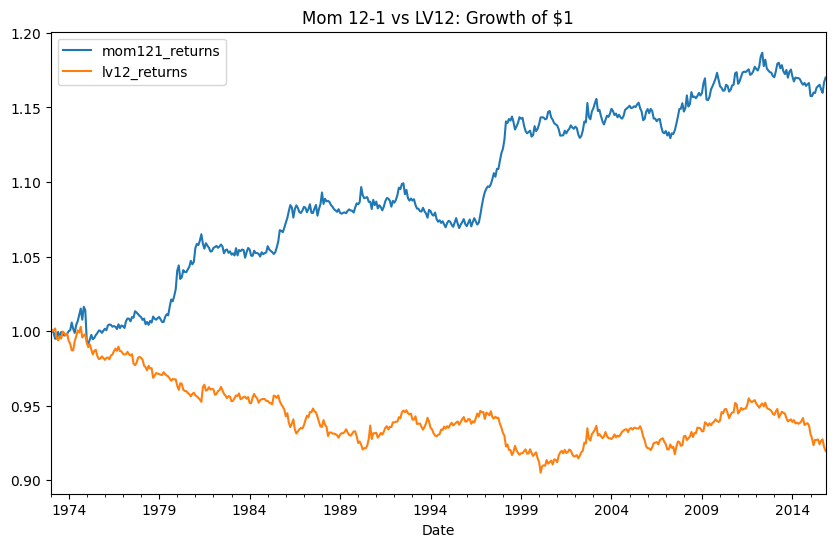

In [56]:
# ---------------------------------------------
# Build and compare Mom 12-1 + LV12 on the same pipeline
# ---------------------------------------------

# 1. Define datasets
train_targets_df = returns.loc["1973-01-31":"2015-11-30"].copy()
test_targets_df = returns.loc["2015-12-31":"2025-12-31"].copy()
full_usable_data = returns.loc["1970-01-31":"2025-12-31"].copy()

# 2. Build rolling annualized asset covariance matrices for the training period
cov_dict, vol_dict, corr_dict, window_map_df = build_asset_cov_matrices(
    full_usable_data,
    train_targets_df,
    look_back=36
)

# 3. Build Mom 12-1 using your homework-style momentum loop
mom121_signal_df, mom121_unscaled_weights_df = build_momentum_factor2(
    full_usable_data,
    train_targets_df,
    start_lag=12,
    end_lag=2,
    name="mom121"
)

# 4. Scale Mom 12-1 to target 1% annual risk
mom121_weights_scaled, mom121_portfolio_risk = scale_factor_to_target_vol(
    mom121_unscaled_weights_df,
    cov_dict,
    target_vol=0.01
)

# 5. Compute Mom 12-1 scaled returns
mom121_returns = compute_factor_returns(
    mom121_weights_scaled,
    train_targets_df,
    name="mom121_returns"
)

# 6. Build LV12 using the new signal-based low-vol loop
lv12_signal_df, lv12_unscaled_weights_df = build_lowvol_factor(
    full_usable_data,
    train_targets_df,
    look_back=12,
    name="lv12"
)

# 7. Scale LV12 to target 1% annual risk
lv12_weights_scaled, lv12_portfolio_risk = scale_factor_to_target_vol(
    lv12_unscaled_weights_df,
    cov_dict,
    target_vol=0.01
)

# 8. Compute LV12 scaled returns
lv12_returns = compute_factor_returns(
    lv12_weights_scaled,
    train_targets_df,
    name="lv12_returns"
)

# 9. Compare first few rows
print("Mom 12-1 scaled returns:")
print(mom121_returns.head())

print("\nLV12 scaled returns:")
print(lv12_returns.head())

print("\nMom 12-1 portfolio risk:")
print(mom121_portfolio_risk.head())

print("\nLV12 portfolio risk:")
print(lv12_portfolio_risk.head())

# 10. Put them side by side
compare_df = pd.DataFrame({
    "mom121_returns": mom121_returns,
    "lv12_returns": lv12_returns
})

# 11. Growth of $1 chart
(1 + compare_df).cumprod().plot(
    title="Mom 12-1 vs LV12: Growth of $1",
    figsize=(10, 6)
)

# 12. Simple summary stats
def factor_summary(r):
    ann_return = r.mean() * 12
    ann_vol = r.std() * (12**0.5)
    ir = ann_return / ann_vol if ann_vol != 0 else np.nan
    growth = (1 + r).cumprod()
    max_dd = (growth / growth.cummax() - 1).min()

    return pd.Series({
        "Arithmetic Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Information Ratio": ir,
        "Max Drawdown": max_dd
    })

summary_df = compare_df.apply(factor_summary).T
summary_fmt = summary_df.copy()
summary_fmt["Arithmetic Annualized Return"] = summary_fmt["Arithmetic Annualized Return"].map(lambda x: f"{x:.4%}")
summary_fmt["Annualized Volatility"] = summary_fmt["Annualized Volatility"].map(lambda x: f"{x:.4%}")
summary_fmt["Information Ratio"] = summary_fmt["Information Ratio"].map(lambda x: f"{x:.4f}")
summary_fmt["Max Drawdown"] = summary_fmt["Max Drawdown"].map(lambda x: f"{x:.4%}")

print("\nSummary stats:")
print(summary_fmt)

# 13. Optional: inspect first row of scaled weights
print("\nFirst row Mom 12-1 scaled weights:")
print(mom121_weights_scaled.iloc[0])

print("\nFirst row LV12 scaled weights:")
print(lv12_weights_scaled.iloc[0])